In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import heapq

## 1. Eventos Discretos en el futuro.
En la estación espacial 108B-42 se establece un protocolo de seguridad donde las naves al llegar deben elegir uno de los 3 pasillos que van hacia los 3 servidores de mantenimiento. Al entrar a un pasillo se incorporan a la cola correspondiente. 
Las salidas de los servidores de mantenimiento llevan a una única cola por la que todas las naves deben pasar para indicar su ruta de viaje y pagar por el paso por la estación espacial. Ese proceso ocurre en los 2 servidores de salida, cuando algún servidor de salida termina una operación, la primera nave en la cola pasa a ese servidor.
La estación espacial cierra sus servicios todas las noches para hacer limpieza y reabastecimiento. A partir de la hora de cierre no entran más naves, pero todas las que ya estaban dentro terminan de ser atendidas.

**a) Realice una modelación e implemente el sistema para simular un día de trabajo en esta estación espacial.** 

**b) Realice las pruebas necesarias para responder preguntas como:**

    - ¿Cuánto tiempo le suele tomar a una nave salir de la estación espacial?

    - ¿Cuánto tiempo después de la hora de cierre la estación queda vacía?

    - ¿Cuál es el servicio más rápido, cuál es el servicio más lento?

    - etc.


**c) Experimente con diferentes distribuciones y/o parámetros, para representar la frecuencia de arribo, el tiempo de procesamiento en cada uno de los 5 servidores, etc.**

**d) Diseñe varias estrategias para escoger el pasillo por el que entran las naves. Luego realice simulaciones con naves diversas, que no siguen todas la misma estrategia. Analice si la estrategia influye en salir más rápido de la estación espacial.**

In [ ]:
class SpaceStationSimulation:
    """
    Simulates the 108B-42 Space Station with:
    - 3 Maintenance Bays (phase 1)
    - 2 Check-Out Service (phase 2)
    - Closing time after which no new ships arrive
    """
    def __init__(self, arrival_rate, maintenance_function, check_out_function, closing_time):
        # Parameters
        self.arrival_rate = arrival_rate # lambda parameter for Poisson
        self.maintenance_function = maintenance_function # function to generate maintenance service time
        self.check_out_function = check_out_function # function to generate check-out service time
        self.closing_time = closing_time
        
        self.rng = np.random.default_rng()
        
        # Simulation state
        self.time = 0
        self.n_ships = 0
        self.events_queue = [] # heap queue containing tuples (t, event) or (t, event, index)
        self.events = {'arrival': self.new_arrival,
                       'end_maintenance': self.maintenance_ended,
                       'departure': self.new_departure}

        self.q_phase1 = [[], [], []]    # Queues for maintenance bays
        self.q_phase2 = []              # Queue for check-out phase
        self.maintenance_status = [-1, -1, -1]  # stores the id of the ship using the server; if none then -1
        self.check_out_status = [-1, -1]         # stores the id of the ship using the server; if none then -1
        
        # Statistics tracking
        self.arrivals = {}                  # arrivals[i] = time of arrival of ship i
        self.maintenances = [{}, {}, {}]    # maintenances[j][i] = time of arrival of ship i to maintenance bay j
        self.begin_phase2 = {}              # begin_phase2[i] = time of arrival of ship i to phase2 (= time end maintenance )
        self.check_outs = [{}, {}]          # check_outs[j][i] = time of arrival of ship i to maintenance service j
        self.departures = {}                # departures[i] = time of departure of ship i
        
    def next_arrival(self):
        if self.time >= self.closing_time:
            return
        ta = self.rng.exponential(1/self.arrival_rate)
        next_ta = self.time + ta
        if next_ta < self.closing_time:
            heapq.heappush(self.events_queue, (next_ta, 'arrival'))
    
    def process_maintenance(self, index, ship_id):
        self.maintenance_status[index] # = 
        self.maintenances[index][ship_id] # = 
        maint_time_end # = 
        heapq.heappush(self.events_queue, (maint_time_end, 'end_maintenance', index))
        
    def process_check_out(self, index, ship_id):
        # code here
        heapq.heappush(self.events_queue, (check_out_time_end, 'departure', index))      
    
    def new_arrival(self): # event
        ship_id = self.n_ships
        self.n_ships += 1
        chosen_queue # = 
        self.arrivals[ship_id] = self.time

        # case 1: bay is empty
        
        # code here
        
        # case 2: send to queue
        
        # code here
            
        # generate the next arrival
        self.next_arrival()

    def maintenance_ended(self, index): # event
        assert(self.maintenance_status[index] >= 0)
        ship_id # = 
        self.begin_phase2[ship_id] # = 
        
        # Process next ship in the maintenance queue
        
        # code here
        
        # send to check-out        
        if self.q_phase2:
            # code here
        else: 
            if not -1 in self.check_out_status:
                # code here
            else:
                # code here
                # code here  
    
    def new_departure(self, index): # event
        assert(self.check_out_status[index] >= 0)
        ship_id # = 
        self.departures[ship_id] # = 
        
        # Process next ship in check-out queue 
        if self.q_phase2:
            # code here
        else: # set to default status
            # code here
    
    def run(self):
        """Run the simulation until all events are processed."""
        self.next_arrival()
        while self.events_queue:
            event_tuple = heapq.heappop(self.events_queue)
            if len(event_tuple) == 2:
                time, event_type = event_tuple
                self.time = time
                assert(event_type == 'arrival')
                self.events[event_type]()
            else:
                time, event_type, index = event_tuple
                self.time = time
                self.events[event_type](index)
                
    def statistics(self):
        time_by_ship = []
        for ship_id in self.arrivals:
            if ship_id in self.departures:
                time_by_ship.append(self.departures[ship_id] - self.arrivals[ship_id])

        maintenance_times = []
        check_out_times = []
        
        for ship_id in self.arrivals:
            maintenance_start = self.arrivals[ship_id]
            maintenance_end = self.begin_phase2[ship_id]
            maintenance_times.append(maintenance_end - maintenance_start)
            
        for ship_id in self.begin_phase2:
            check_out_start = self.begin_phase2[ship_id]
            check_out_end = self.departures[ship_id]
            check_out_times.append(check_out_end - check_out_start)
            
        return {
            'time_by_ship': time_by_ship,
            'maintenance_times': maintenance_times,
            'check_out_times': check_out_times,
        }
        

In [ ]:
def maintenance_time():
    # code here
    pass
def check_out_time():
    # code here
    pass

# Initialize and run simulation
sim = SpaceStationSimulation(
    arrival_rate = 2,
    maintenance_function = maintenance_time,
    check_out_function = check_out_time,
    closing_time = 50  
)
sim.run()

In [ ]:
plt.figure(figsize=(12, 8))
    
# Plot each ship's journey
for ship_id in range(sim.n_ships):
    arrival_time = sim.arrivals[ship_id]
    for bay in range(3):
        if ship_id in sim.maintenances[bay]:
            maint_bay = bay
            maint_start = sim.maintenances[bay][ship_id]
            break
    maint_end = sim.begin_phase2[ship_id]
    checkout_server = None
    for server in range(2):
        if ship_id in sim.check_outs[server]:
            checkout_server = server
            checkout_start = sim.check_outs[server][ship_id]
            break
    departure_time = sim.departures[ship_id]
    
    # Plot the timeline
    plt.plot([arrival_time, maint_start], [ship_id, ship_id], 'b-', alpha=0.5)          # Waiting for maintenance
    plt.plot([maint_start, maint_end], [ship_id, ship_id], 'g-', linewidth=2)           # Maintenance
    plt.plot([maint_end, checkout_start], [ship_id, ship_id], 'b-', alpha=0.5)          # Waiting for checkout
    plt.plot([checkout_start, departure_time], [ship_id, ship_id], 'r-', linewidth=2)   # Checkout

    # Add markers
    plt.plot(arrival_time, ship_id, 'bo', label='Arrival' if ship_id == 0 else "")
    plt.plot(maint_start, ship_id, 'g>', label='Maintenance Start' if ship_id == 0 else "")
    plt.plot(maint_end, ship_id, 'g<', label='Maintenance End' if ship_id == 0 else "")
    plt.plot(checkout_start, ship_id, 'r>', label='Checkout Start' if ship_id == 0 else "")
    plt.plot(departure_time, ship_id, 'ro', label='Departure' if ship_id == 0 else "")

# Add vertical line for closing time
plt.axvline(x=sim.closing_time, color='k', linestyle='--', label='Closing Time')

# Formatting
plt.title("Ship Processing Timeline")
plt.xlabel("Time")
plt.ylabel("Ship ID")
plt.xlim(-5, max(sim.departures.values()) + 5)
plt.ylim(-5, sim.n_ships + 5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
st = sim.statistics()

AttributeError: 'RobotAssemblySimulation' object has no attribute 'n_ships'

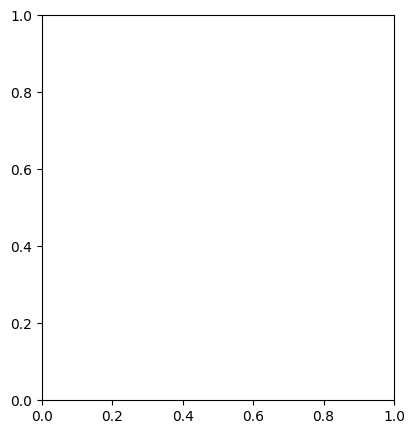

In [ ]:
# - ¿Cuánto tiempo le suele tomar a una nave salir de la estación espacial?

plt.figure(figsize=(6, 4))
plt.stem(range(sim.n_ships), st['time_by_ship'], 'C1-')
plt.title('Tiempo total en la estación por nave')
plt.xlabel('Naves')
plt.ylabel('Tiempo')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Tiempo promedio en la estación: {np.mean(st['time_by_ship']):.1f} minutos")
print(f"Mediana de tiempo en la estación: {np.median(st['time_by_ship']):.1f} minutos")
print(f"Rango medio: {np.percentile(st['time_by_ship'], 25):.1f} - {np.percentile(st['time_by_ship'], 75):.1f} minutos")


In [ ]:
# - ¿Cuánto tiempo después de la hora de cierre la estación queda vacía?

# code here

In [ ]:
# - ¿Cuál es el servicio más rápido, cuál es el servicio más lento?
plt.figure(figsize=(12, 5))

max_y = max(max(st['maintenance_times']), max(st['check_out_times'])) * 1.05

plt.subplot(1, 2, 1)
plt.stem(range(sim.n_ships), st['maintenance_times'], 'C2-')
plt.title('Tiempos de Mantenimiento')
plt.xlabel('Naves')
plt.ylabel('Tiempo')
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, max_y)

plt.subplot(1, 2, 2)
plt.stem(range(sim.n_ships), st['check_out_times'], 'C3-')
plt.title('Tiempos de Check-out')
plt.xlabel('Naves')
plt.ylabel('Tiempo')
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, max_y)

plt.show()

## 2. Dónde está mi robot?
La fábrica donde se termina la construcción de naves espaciales de última generación, necesita $N$ robots ensambladores trabajando para mantenerse funcional. 
Como medida de respaldo se tienen algunos robots de repuesto. Si un robot se rompe, se sustituye por uno de repuesto, y se envía a reparar. Los robots se rompen siguiendo una función de distribución F. 

Las reparaciones las realiza el Dr. Farnsworth, que solo puede arreglar uno a la vez. Cada reparación toma un tiempo que distribuye normal. Cuando un robot es reparado se incorpora a las filas de los robots de repuesto. 

Si se rompe un robot y no hay repuestos disponibles el sistema de ensamblaje falla catastróficamente.

**Asumiendo que se comienza con $N+s$ ($s<N$) robots, donde los s son los repuestos iniciales, simule el funcionamiento de la fábrica para aproximar el valor CT, que indica el tiempo esperado en que falla el sistema.**

In [ ]:
import numpy as np
import heapq

In [ ]:
class RobotAssemblySimulation:
    def __init__(self, N, s, failure_function, repair_function, num_simulations=1000):
        # Parameters
        self.N = N
        self.s = s
        self.failure_function = failure_function
        self.repair_function = repair_function
        self.num_simulations = num_simulations
        self.failure_times = []
    
    def simulations(self):
        for i in range(self.num_simulations):
            # Initialize simulation
            current_time = 0
            working_robots = self.N
            spare_robots = self.s
            repair_queue = []
            events_queue = []
            self.run(current_time, working_robots, spare_robots, repair_queue, events_queue)

    def run(self, current_time, working_robots, spare_robots, repair_queue, events_queue):
        # Schedule initial failures
        for i in range(working_robots):
            failure_time # = 
            heapq.heappush(events_queue, (failure_time, 'failure'))
        repairing = False
        while True:
            # Get the next event (failure or repair completion)
            current_time, event_type = heapq.heappop(events_queue)
            
            if event_type == 'failure':
                # code here
            else:
                # code here


In [ ]:
def failure_time():
    # code here
    pass
def repair_time():
    # code here
    pass
NS = 1000
sim = RobotAssemblySimulation(10, 3, failure_time, repair_time, num_simulations=NS)
sim.simulations()

In [ ]:
CT = np.mean(sim.failure_times)
print(f"Tiempo esperado de falla (CT): {CT:.2f}")

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(range(NS), sim.failure_times)
plt.title('Tiempos de roturas')
plt.xlabel('Simulación')
plt.ylabel('Tiempo')
plt.ylim(0, max(sim.failure_times)+1)
plt.grid(True, alpha=0.3)